In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df=pd.read_csv('car_price.csv')
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016.0,8680.0,Manual,25906.0,Diesel,0.0,78.4,1.6,Hyundai
72431,I40,2015.0,7830.0,Manual,NaN,Diesel,30.0,65.7,1.7,Hyundai
72432,I10,2017.0,6830.0,Manual,13810.0,Petrol,20.0,60.1,1.0,NaN
72433,Tucson,2018.0,13994.0,Manual,23313.0,Petrol,145.0,44.8,1.6,Hyundai


In [42]:
print(f'Shape: {df.shape}')

Shape: (72435, 10)


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


In [44]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


In [45]:
n_col = df.select_dtypes(include=np.number).columns.tolist()
n_col

['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']

In [46]:
c_col = df.select_dtypes(include=np.object_).columns.tolist()
c_col

['model', 'transmission', 'fuelType', 'Make']

In [47]:
df.isnull().sum()

,0
model,3621
year,3622
price,3621
transmission,3623
mileage,3622
fuelType,3622
tax,3621
mpg,3621
engineSize,3622
Make,3621


In [48]:
df.isnull().sum().sum()

np.int64(36216)

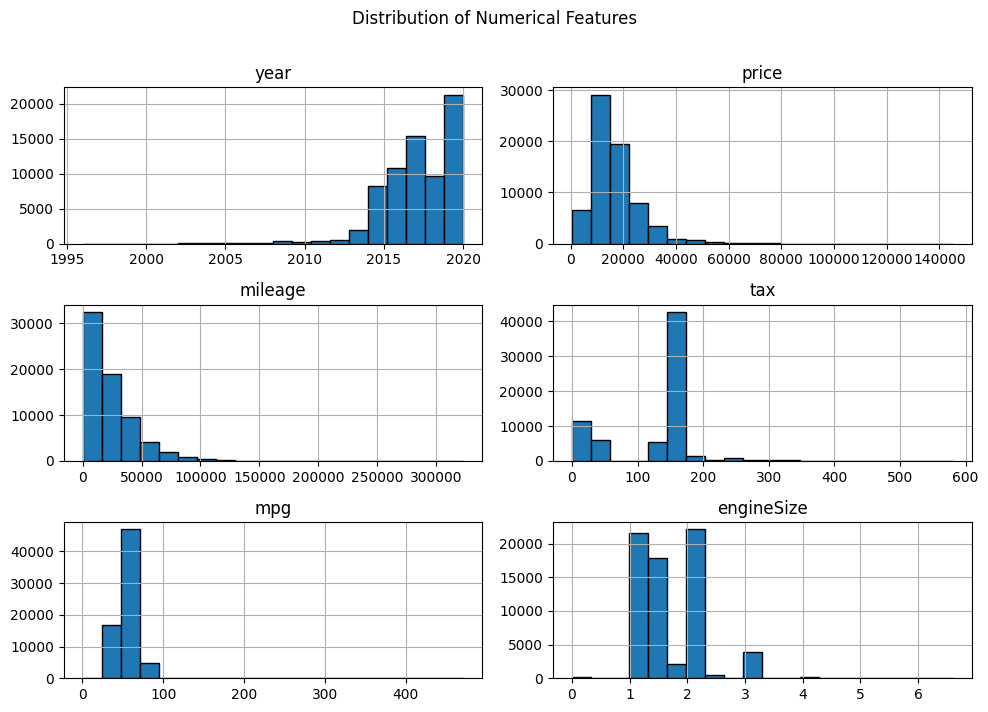

In [50]:
df[n_col].hist(figsize=(10,7), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

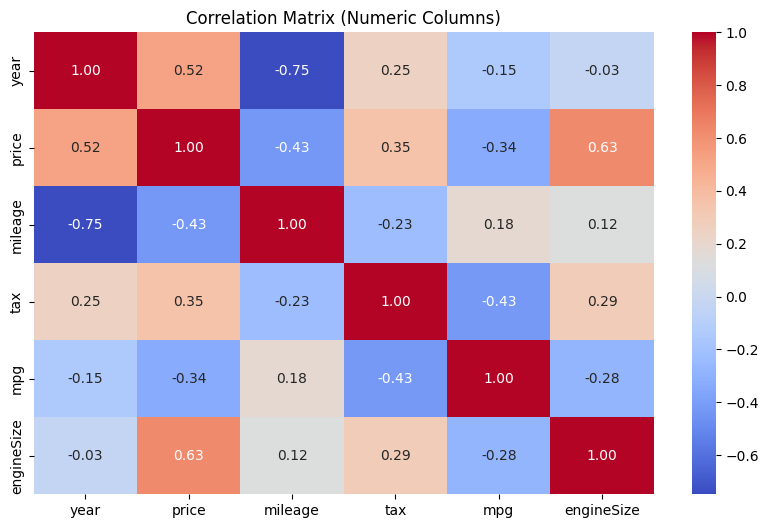

features seem most related to price is: engineSize


In [56]:
plt.figure(figsize=(10, 6))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix,
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numeric Columns)")
plt.show()

price_correlations = correlation_matrix['price']
top_feature = price_correlations.drop('price').abs().idxmax()
print(f"features seem most related to price is: {top_feature}")